# Team 2: Model Development & Tuning

**Team 1 handoff:** `bescom_preprocessed_final.csv` + `scale_columns.json`  
**Team 2 scope:** Data leakage audit → Train/Val/Test split → Scaling → Baseline models → Hyperparameter tuning → SHAP explainability → Final model export

---
##  MEMBER D - SHAP Explainability + Final Export + Recommendation Engine

SHAP computed on 1,439 test samples.

Top-10 features by mean |SHAP|:


,mean |SHAP|
hist_avg_units,30.386000
month_sin,19.381001
days_home,18.079000
baseload_kwh,17.125999
month_cos,15.521000
total_hca_kwh,9.253000
num_people,7.236000
has_any_ac,3.429000
geyser_kwh,2.992000
microwave_kwh,2.507000


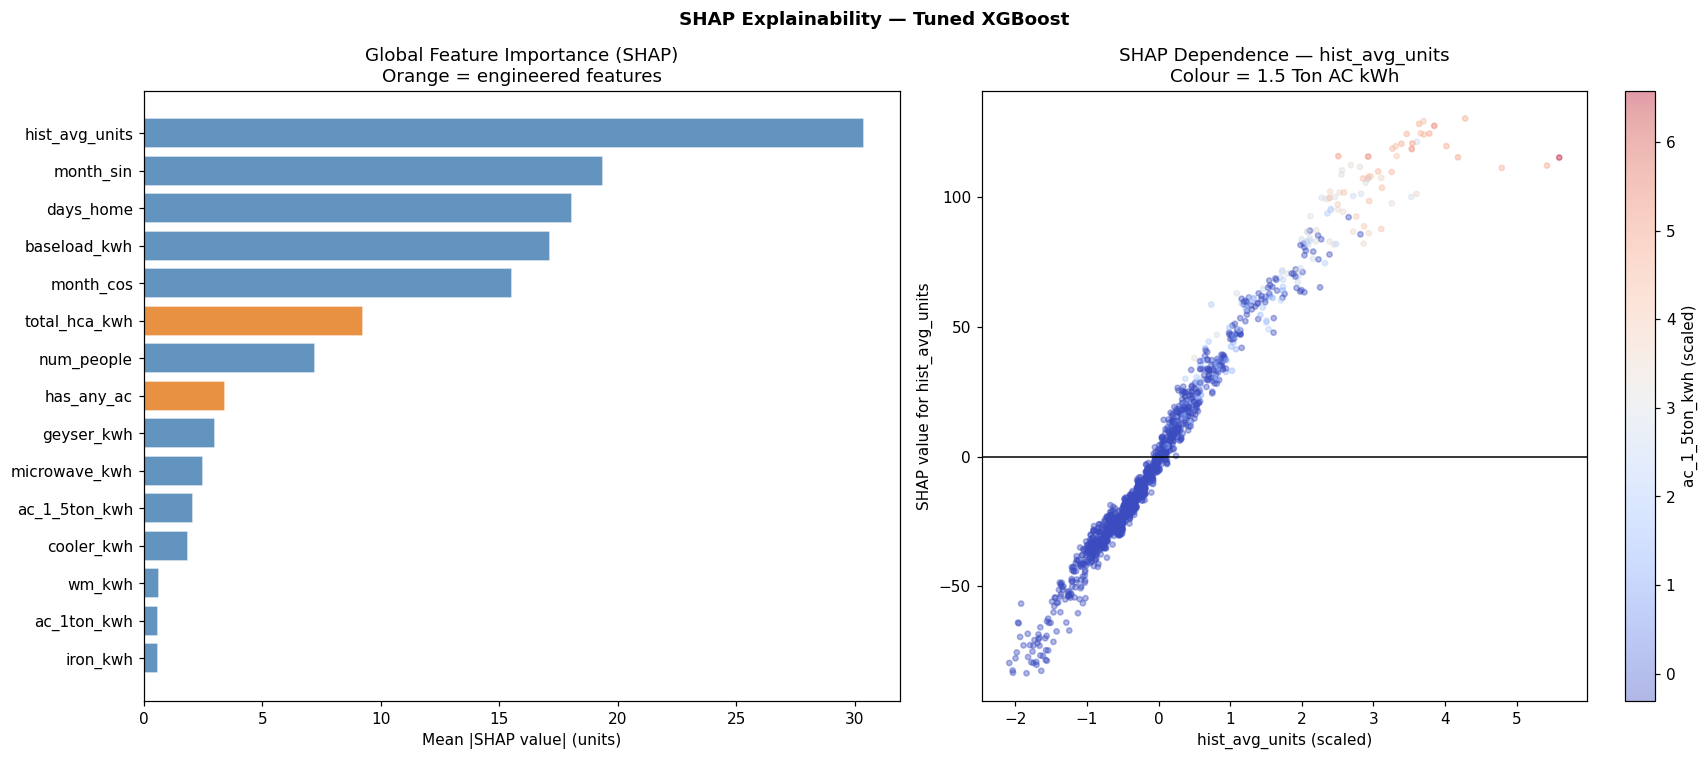

In [26]:
# ─────────────────────────────────────────────────────────────
# CELL 10 · SHAP Feature Importance
# ─────────────────────────────────────────────────────────────
# SHAP (SHapley Additive exPlanations) explains EACH prediction.
# For each row: SHAP value for feature X = how many units that
# feature pushed the prediction up or down from the mean.
#
# Why this matters for the mentor:
#   • Proves the model learned physics — AC features dominate in summer
#   • Identifies which appliance to recommend reducing
#   • Makes the black-box model explainable to non-technical users

# Use TreeExplainer (fast, exact for tree models)
explainer  = shap.TreeExplainer(tuned_xgb)
shap_vals  = explainer.shap_values(X_test_sc)  # shape: (n_test, n_features)

shap_df = pd.DataFrame(shap_vals, columns=ALL_FEATURES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f'SHAP computed on {len(X_test_sc):,} test samples.')
print('\nTop-10 features by mean |SHAP|:')
display(mean_abs_shap.head(10).to_frame('mean |SHAP|').round(3))

# ── SHAP Summary (Beeswarm) Plot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar plot — global importance
ax = axes[0]
top_features = mean_abs_shap.head(15)
colors_shap  = ['#e67e22' if f in {'has_any_ac','has_ac_1ton','has_ac_1_5ton',
                                    'total_hca_kwh','partial_month','high_occupancy'}
                else 'steelblue' for f in top_features.index]
ax.barh(top_features.index[::-1], top_features.values[::-1],
        color=colors_shap[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (units)')
ax.set_title('Global Feature Importance (SHAP)\nOrange = engineered features')

# SHAP dependence for hist_avg_units (most important)
ax2 = axes[1]
feat = 'hist_avg_units'
feat_idx = list(ALL_FEATURES).index(feat)
sc = ax2.scatter(
    X_test_sc[feat],
    shap_df[feat],
    c=X_test_sc['ac_1_5ton_kwh'],
    cmap='coolwarm', alpha=0.4, s=12
)
plt.colorbar(sc, ax=ax2, label='ac_1_5ton_kwh (scaled)')
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel(f'{feat} (scaled)')
ax2.set_ylabel(f'SHAP value for {feat}')
ax2.set_title('SHAP Dependence — hist_avg_units\n'
              'Colour = 1.5 Ton AC kWh')

plt.suptitle('SHAP Explainability — Tuned XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

Example household:
  Actual units    : 226.3
  Predicted units : 218.6
  Error           : -7.7 units

Top SHAP contributions for this household:


,Feature,SHAP value,Feature value (scaled)
21,total_hca_kwh,-16.237,-0.730
0,hist_avg_units,-13.815,-0.101
6,baseload_kwh,12.235,0.552
5,month_cos,-4.855,1.201
3,days_home,4.566,0.356
4,month_sin,4.232,-0.689
9,geyser_kwh,-3.263,-0.588
2,num_people,2.350,0.233
22,has_any_ac,1.979,0.000
1,hist_trend,1.748,-0.574


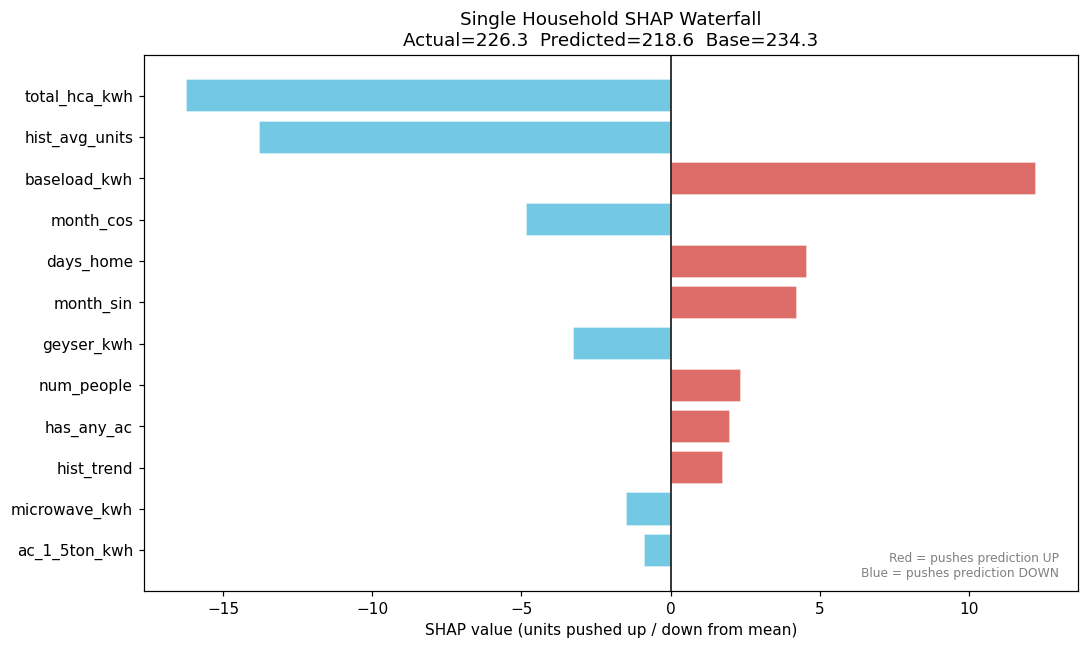


This waterfall shows the mentor EXACTLY why the model predicted
that number — not a black box.


In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 11 · SHAP Waterfall for a Single Prediction
# ─────────────────────────────────────────────────────────────
# Pick one test household and show exactly WHY the model predicted
# that number — which features pushed it up / down.
# This is what the recommendation engine will use per user.

# Pick the household closest to median actual_units
median_actual = np.median(y_test.values)
sample_idx_in_test = np.argmin(np.abs(y_test.values - median_actual))

sample_row   = X_test_sc.iloc[[sample_idx_in_test]]
sample_actual = y_test.values[sample_idx_in_test]
sample_pred   = tuned_xgb.predict(sample_row)[0]
sample_shap   = shap_vals[sample_idx_in_test]

print(f'Example household:')
print(f'  Actual units    : {sample_actual:.1f}')
print(f'  Predicted units : {sample_pred:.1f}')
print(f'  Error           : {sample_pred - sample_actual:.1f} units')
print()

# Top contributing features for this household
sample_shap_df = pd.DataFrame({
    'Feature'   : ALL_FEATURES,
    'SHAP value': sample_shap,
    'Feature value (scaled)': sample_row.values[0]
}).sort_values('SHAP value', key=abs, ascending=False).head(12)

print('Top SHAP contributions for this household:')
display(sample_shap_df.round(3))

# Waterfall-style bar chart
fig, ax = plt.subplots(figsize=(10, 6))

top12 = sample_shap_df.head(12).iloc[::-1]
colors_wf = ['#d9534f' if v > 0 else '#5bc0de' for v in top12['SHAP value']]
ax.barh(top12['Feature'], top12['SHAP value'],
        color=colors_wf, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('SHAP value (units pushed up / down from mean)')
ax.set_title(f'Single Household SHAP Waterfall\n'
             f'Actual={sample_actual:.1f}  Predicted={sample_pred:.1f}  '
             f'Base={explainer.expected_value:.1f}')
ax.text(0.98, 0.02, 'Red = pushes prediction UP\nBlue = pushes prediction DOWN',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print()
print('This waterfall shows the mentor EXACTLY why the model predicted')
print('that number — not a black box.')

In [28]:
# CELL 12 · Final Summary Table + Model + Recommendation Engine
# PART A: Final comparison table across ALL models
final_df = pd.DataFrame(results_log)
print('=' * 70)
print('  FINAL MODEL COMPARISON')
print('=' * 70)
display(final_df.style.highlight_max(subset=['Val R²'], color='lightgreen')
                      .highlight_min(subset=['Val MAE'], color='lightgreen'))
print()
print(f'  Selected model : XGBoost (Optuna tuned)')
print(f'  Test R²        : {test_r2:.4f}')
print(f'  Test MAE       : {test_mae:.2f} units')
print(f'  Test RMSE      : {test_rmse:.2f} units')
print(f'  5-Fold CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

# ─────────────────────────────────────────────────────────────
# PART B: Save model and scaler
# ─────────────────────────────────────────────────────────────
joblib.dump(tuned_xgb,   'model_xgb_tuned.pkl')
joblib.dump(scaler,      'scaler_team2.pkl')

# Save SHAP explainer for deployment
joblib.dump(explainer, 'shap_explainer.pkl')

# Save feature list (Team 3 must use exactly this order)
with open('feature_order.json', 'w') as f:
    json.dump(ALL_FEATURES, f, indent=2)

print()
print('Files saved:')
print('  model_xgb_tuned.pkl    — trained XGBoost model')
print('  scaler_team2.pkl       — StandardScaler (fit on train only)')
print('  shap_explainer.pkl     — SHAP TreeExplainer')
print('  feature_order.json     — exact feature column order for inference')

# ─────────────────────────────────────────────────────────────
# PART C: Recommendation Engine (stub for Team 3)
# ─────────────────────────────────────────────────────────────
# This function takes a user's input dict, runs the model,
# and returns a personalised recommendation.

def predict_and_recommend(
    user_input: dict,
    model_path: str = 'model_xgb_tuned.pkl',
    scaler_path: str = 'scaler_team2.pkl',
    feature_path: str = 'feature_order.json'
):
    """
    Parameters
    ----------
    user_input : dict with keys matching ALL_FEATURES.
        Example:
        {
            'hist_avg_units': 185.0,
            'hist_trend'    : 10.0,
            'num_people'    : 3,
            'days_home'     : 30,
            'month_sin'     : 0.5,
            'month_cos'     : 0.866,
            'baseload_kwh'  : 120.0,
            'ac_1ton_kwh'   : 0.0,
            'ac_1_5ton_kwh' : 270.0,
            'geyser_kwh'    : 30.0,
            'wm_kwh'        : 10.0,
            'microwave_kwh' : 18.0,
            'cooler_kwh'    : 0.0,
            'iron_kwh'      : 6.5,
            'has_ac_1ton'   : 0,
            'has_ac_1_5ton' : 1,
            'has_geyser'    : 1,
            'has_wm'        : 1,
            'has_microwave' : 1,
            'has_cooler'    : 0,
            'has_iron'      : 1,
            'total_hca_kwh' : 334.5,
            'has_any_ac'    : 1,
            'high_occupancy': 0,
            'partial_month' : 0,
        }

    Returns
    -------
    dict with predicted_units, entitlement_limit, status, recommendations
    """
    import joblib, json
    import pandas as pd
    import numpy as np

    model   = joblib.load(model_path)
    scaler  = joblib.load(scaler_path)
    with open(feature_path) as fh:
        feature_order = json.load(fh)

    BINARY_COLS = [
        'has_ac_1ton', 'has_ac_1_5ton', 'has_geyser',
        'has_wm', 'has_microwave', 'has_cooler', 'has_iron',
        'has_any_ac', 'high_occupancy', 'partial_month'
    ]
    scale_cols = [c for c in feature_order if c not in BINARY_COLS]

    # Build input DataFrame in correct column order
    row = pd.DataFrame([user_input])[feature_order]
    row[scale_cols] = scaler.transform(row[scale_cols])

    predicted_units = float(model.predict(row)[0])

    # Entitlement
    hist_avg         = user_input['hist_avg_units']
    entitlement      = min(hist_avg * 1.10, 200)
    units_over       = max(0, predicted_units - entitlement)
    pct_over         = (units_over / entitlement) * 100 if entitlement > 0 else 0

    if units_over <= 0:
        status = 'SAFE — within Gruha Jyoti entitlement'
    elif units_over <= 20:
        status = 'BORDERLINE — small reduction saves full bill'
    else:
        status = 'OVER — significant bill expected'

    # Identify top appliance to cut (by kWh column — biggest mover)
    hca_map = {
        'ac_1ton_kwh'    : '1 Ton AC',
        'ac_1_5ton_kwh'  : '1.5 Ton AC',
        'geyser_kwh'     : 'Geyser',
        'wm_kwh'         : 'Washing Machine',
        'microwave_kwh'  : 'Microwave',
        'cooler_kwh'     : 'Air Cooler',
        'iron_kwh'       : 'Iron'
    }
    appliance_kwh = {
        name: user_input.get(col, 0)
        for col, name in hca_map.items()
    }
    top_appliance = max(appliance_kwh, key=appliance_kwh.get)
    top_kwh       = appliance_kwh[top_appliance]

    recommendations = []
    if units_over > 0:
        saving_needed = units_over + 5  # small buffer
        recommendations.append(
            f'Reduce {top_appliance} usage by ~{saving_needed:.0f} units '
            f'(currently {top_kwh:.1f} kWh/month, ~{top_kwh/30:.1f} kWh/day)'
        )
        if user_input.get('has_geyser', 0) == 1 and user_input.get('geyser_kwh', 0) > 15:
            recommendations.append(
                'Set geyser timer to 20 min/day — saves ~6 units/month'
            )
        if user_input.get('has_ac_1_5ton', 0) == 1:
            recommendations.append(
                'Set AC temperature to 24°C (BEE recommendation) — saves ~8% AC energy'
            )

    return {
        'predicted_units'   : round(predicted_units, 1),
        'entitlement_limit' : round(entitlement, 1),
        'units_over'        : round(units_over, 1),
        'status'            : status,
        'recommendations'   : recommendations
    }


# ── Demo run ──────────────────────────────────────────────────
demo_input = {
    'hist_avg_units': 185.0,
    'hist_trend'    : 10.0,
    'num_people'    : 3,
    'days_home'     : 30,
    'month_sin'     : 0.5,    # April
    'month_cos'     : 0.866,
    'baseload_kwh'  : 120.0,
    'ac_1ton_kwh'   : 0.0,
    'ac_1_5ton_kwh' : 270.0,  # 1.5T AC, 6hrs/day, April
    'geyser_kwh'    : 30.0,
    'wm_kwh'        : 10.0,
    'microwave_kwh' : 18.0,
    'cooler_kwh'    : 0.0,
    'iron_kwh'      : 6.5,
    'has_ac_1ton'   : 0,
    'has_ac_1_5ton' : 1,
    'has_geyser'    : 1,
    'has_wm'        : 1,
    'has_microwave' : 1,
    'has_cooler'    : 0,
    'has_iron'      : 1,
    'total_hca_kwh' : 334.5,
    'has_any_ac'    : 1,
    'high_occupancy': 0,
    'partial_month' : 0,
}

result = predict_and_recommend(demo_input)

print('\n' + '=' * 55)
print('  RECOMMENDATION ENGINE — DEMO OUTPUT')
print('=' * 55)
print(f'  Predicted units : {result["predicted_units"]} kWh')
print(f'  Entitlement     : {result["entitlement_limit"]} units')
print(f'  Units over      : {result["units_over"]}')
print(f'  Status          : {result["status"]}')
print()
if result['recommendations']:
    print('  Recommendations:')
    for i, r in enumerate(result['recommendations'], 1):
        print(f'    {i}. {r}')
else:
    print('  No action needed — you are within your free entitlement!')
print('=' * 55)

  FINAL MODEL COMPARISON


,Model,Train R²,Val R²,Train MAE,Val MAE,Train RMSE,Val RMSE,Overfit?
0,Linear Regression,0.734500,0.743700,32.400000,32.960000,39.940000,39.880000,NO
1,Ridge (alpha=10),0.734400,0.743500,32.400000,32.970000,39.940000,39.900000,NO
2,Lasso (alpha=0.1),0.734100,0.742900,32.440000,33.010000,39.960000,39.940000,NO
3,Random Forest (100 trees),0.942900,0.879500,14.050000,20.660000,18.520000,27.350000,NO
4,XGBoost,0.967700,0.907400,10.990000,17.990000,13.940000,23.970000,NO
5,XGBoost (Optuna tuned),0.951200,0.912700,13.460000,17.550000,17.130000,23.280000,NO



  Selected model : XGBoost (Optuna tuned)
  Test R²        : 0.9159
  Test MAE       : 17.56 units
  Test RMSE      : 22.57 units
  5-Fold CV R²   : 0.9104 ± 0.0014

Files saved:
  model_xgb_tuned.pkl    — trained XGBoost model
  scaler_team2.pkl       — StandardScaler (fit on train only)
  shap_explainer.pkl     — SHAP TreeExplainer
  feature_order.json     — exact feature column order for inference

  RECOMMENDATION ENGINE — DEMO OUTPUT
  Predicted units : 208.4 kWh
  Entitlement     : 200 units
  Units over      : 8.4
  Status          : BORDERLINE — small reduction saves full bill

  Recommendations:
    1. Reduce 1.5 Ton AC usage by ~13 units (currently 270.0 kWh/month, ~9.0 kWh/day)
    2. Set geyser timer to 20 min/day — saves ~6 units/month
    3. Set AC temperature to 24°C (BEE recommendation) — saves ~8% AC energy
